# Bloombot Conversation Analytics

Analyzes message and user data from `data/data.db` to surface:
- Message volume by course, semester, and channel type
- User engagement patterns
- Conversation groupings (rapid back-and-forth exchanges within a time window)
- AI-powered topic classification per course and semester

**Prerequisites:** `OPENAI_API_KEY` in `.env` is required for topic classification in Section 4.

In [7]:
# Uncomment to install analysis libraries if not already available
# !pip install pandas matplotlib seaborn numpy

In [8]:
import sqlite3
import re
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# ── Paths ────────────────────────────────────────────────────────────
DB_PATH    = Path('./data/data.db')
CACHE_PATH = Path('./data/topic_classifications.json')

# ── Conversation grouping ─────────────────────────────────────────────
GAP_MINUTES = 30  # silence gap (minutes) that signals a new conversation

# ── Map Discord category prefixes → readable course names ─────────────
COURSE_MAP = {
    'Software Engineering': 'Software Engineering',
    'Agile Dev':            'Agile Software Development & DevOps',
    'Python':               'Introduction to Programming',
    'Web Design':           'Web Design',
}

# ── Conversation topic labels ─────────────────────────────────────────
TOPICS = [
    'Course material & content',
    'Assignments & homework',
    'Syllabus, schedule & deadlines',
    'Technical setup & tools',
    'Grades & assessment',
    'Professor & office hours',
    'Team projects & collaboration',
    'Resources & references',
    'Other',
]

CLASSIFICATION_MODEL = 'gpt-4o-mini'  # cheap/fast model for batch classification

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (13, 5)

## 1. Load & Prepare Data

In [9]:
conn = sqlite3.connect(DB_PATH)

msgs = pd.read_sql_query(
    '''
    SELECT m.id, m.created_at, m.content, m.category,
           m.channel, m.direction, m.user_id,
           u.discord_username
    FROM messages m
    JOIN users u ON m.user_id = u.id
    ORDER BY m.created_at
    ''',
    conn,
)
users = pd.read_sql_query('SELECT * FROM users', conn)
conn.close()

msgs['created_at'] = pd.to_datetime(msgs['created_at'])
print(len(msgs), 'messages,', msgs['user_id'].nunique(), 'unique users')
msgs.head(3)

444 messages, 46 unique users


,id,created_at,content,category,channel,direction,user_id,discord_username
0,1,2026-01-26 16:25:16.660738,<@1328738160850632825> - what help resources a...,Software Engineering - GLOBAL,test,from,1,foo.barstein
1,2,2026-01-26 16:25:24.960744,@foo.barstein - Help resources for the Softwar...,Software Engineering - GLOBAL,test,to,1,foo.barstein
2,3,2026-01-26 16:27:02.835846,<@1328738160850632825> - is tutoring available?,Software Engineering - GLOBAL,test,from,1,foo.barstein


In [10]:
def get_course(cat):
    prefix = cat.split(' - ')[0]
    return COURSE_MAP.get(prefix, prefix)

def get_channel_type(cat):
    suffix = cat.split(' - ')[-1].upper() if ' - ' in cat else ''
    if 'GLOBAL'  in suffix: return 'Global'
    if 'STUDENT' in suffix: return 'Students'
    if 'TEAM'    in suffix: return 'Teams'
    return 'Other'

def get_semester(dt):
    m, y = dt.month, dt.year
    if m <= 5:  return 'Spring ' + str(y)
    if m <= 8:  return 'Summer ' + str(y)
    return 'Fall ' + str(y)

msgs['course']       = msgs['category'].apply(get_course)
msgs['channel_type'] = msgs['category'].apply(get_channel_type)
msgs['semester']     = msgs['created_at'].apply(get_semester)
msgs['week']         = msgs['created_at'].dt.to_period('W').dt.start_time

msgs[['category', 'course', 'channel_type', 'semester']].drop_duplicates().sort_values('course')

,category,course,channel_type,semester
14,Agile Dev - GLOBAL,Agile Software Development & DevOps,Global,Spring 2026
32,Agile Dev - STUDENTS 01,Agile Software Development & DevOps,Students,Spring 2026
48,Agile Dev - STUDENTS 02,Agile Software Development & DevOps,Students,Spring 2026
404,Agile Dev - TEAMS 01,Agile Software Development & DevOps,Teams,Spring 2026
0,Software Engineering - GLOBAL,Software Engineering,Global,Spring 2026
28,Software Engineering - STUDENTS 01,Software Engineering,Students,Spring 2026
60,Software Engineering - STUDENTS 02,Software Engineering,Students,Spring 2026
70,Software Engineering - TEAMS 01,Software Engineering,Teams,Spring 2026
120,Software Engineering - STUDENTS 05,Software Engineering,Students,Spring 2026
157,Software Engineering - TEAMS 02,Software Engineering,Teams,Spring 2026


## 2. Message Overview

In [11]:
summary = (
    msgs.groupby(['course', 'semester'])
    .agg(
        messages     = ('id',          'count'),
        unique_users = ('user_id',     'nunique'),
        from_user    = ('direction',   lambda x: (x == 'from').sum()),
        to_user      = ('direction',   lambda x: (x == 'to').sum()),
    )
    .reset_index()
)
print(summary.to_string(index=False))

                             course    semester  messages  unique_users  from_user  to_user
Agile Software Development & DevOps Spring 2026        50             5         26       24
               Software Engineering Spring 2026       394            42        202      192


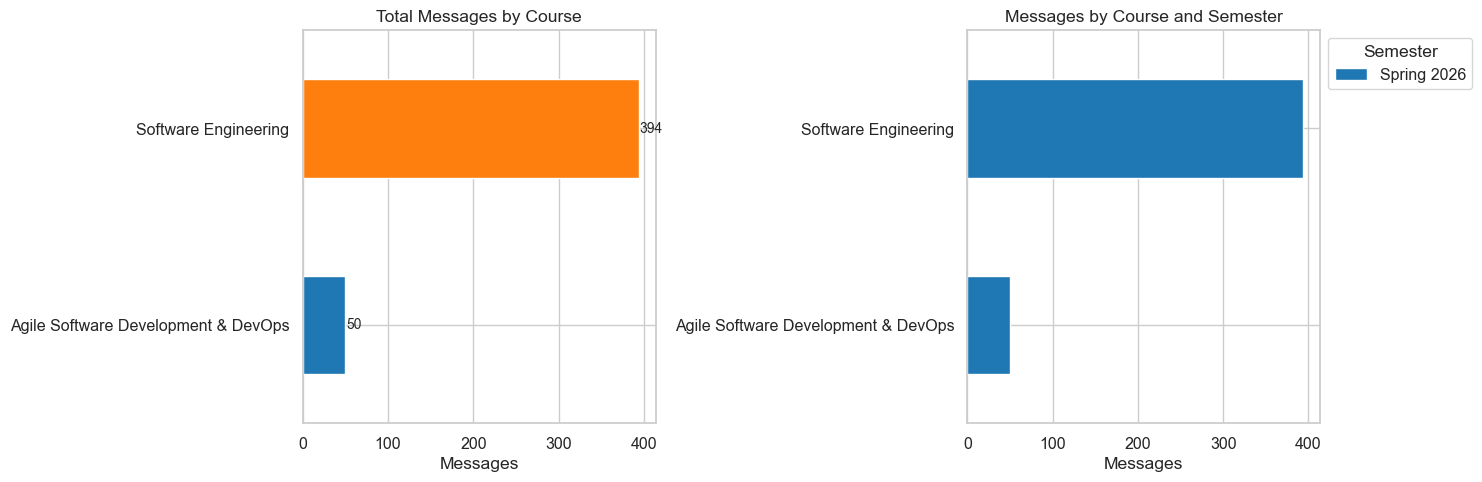

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: total messages by course
course_totals = msgs.groupby('course')['id'].count().sort_values()
colors = sns.color_palette('tab10', len(course_totals))
course_totals.plot.barh(ax=axes[0], color=colors)
axes[0].set_title('Total Messages by Course')
axes[0].set_xlabel('Messages')
axes[0].set_ylabel('')
for bar, val in zip(axes[0].patches, course_totals):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)

# Right: messages by course + semester (stacked)
pivot = (
    msgs.groupby(['course', 'semester'])['id']
    .count()
    .unstack(fill_value=0)
)
pivot.plot.barh(ax=axes[1], stacked=True, colormap='tab20')
axes[1].set_title('Messages by Course and Semester')
axes[1].set_xlabel('Messages')
axes[1].set_ylabel('')
axes[1].legend(title='Semester', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

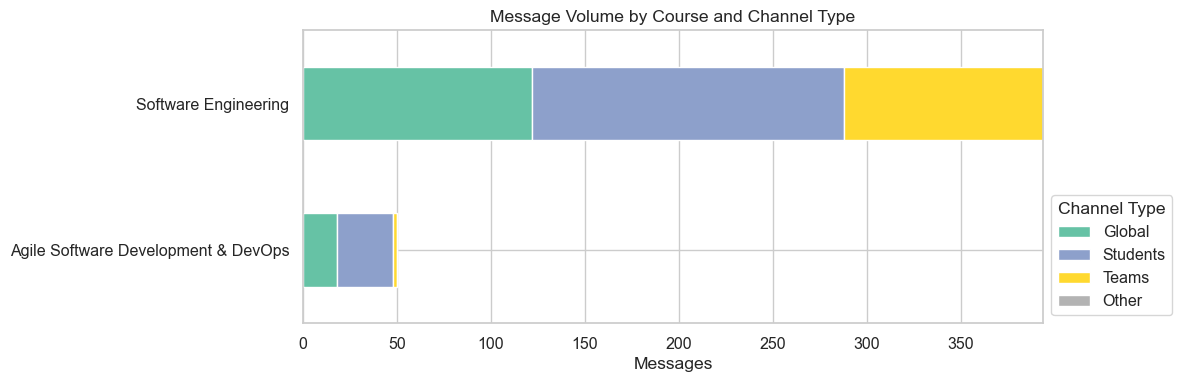

In [13]:
ct_pivot = (
    msgs.groupby(['course', 'channel_type'])['id']
    .count()
    .unstack(fill_value=0)
    .reindex(columns=['Global', 'Students', 'Teams', 'Other'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
ct_pivot.plot.barh(stacked=True, ax=ax, colormap='Set2')
ax.set_title('Message Volume by Course and Channel Type')
ax.set_xlabel('Messages')
ax.set_ylabel('')
ax.legend(title='Channel Type', bbox_to_anchor=(1, 0), loc='lower left')
plt.tight_layout()
plt.show()

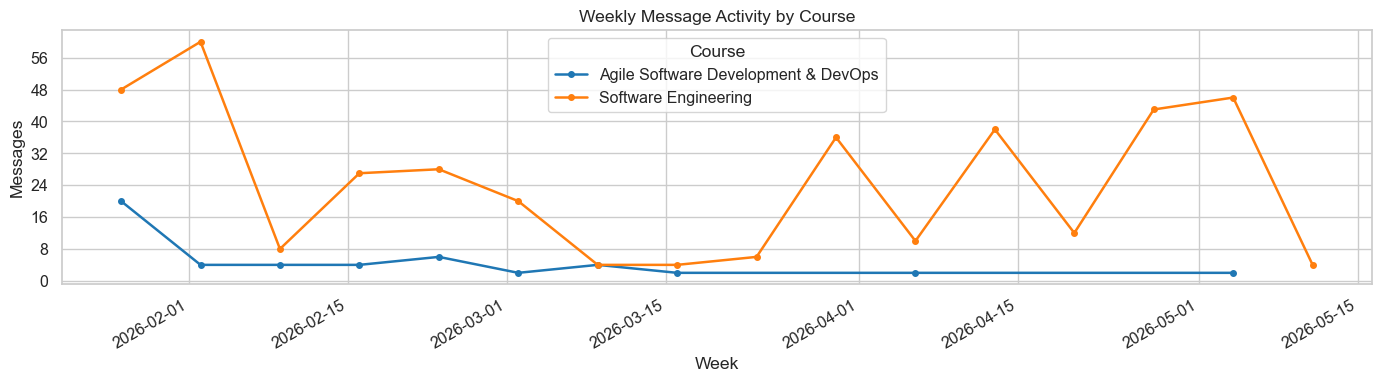

In [14]:
weekly = (
    msgs.groupby(['week', 'course'])['id']
    .count()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(14, 4))
palette = sns.color_palette('tab10', weekly['course'].nunique())
for (course, grp), color in zip(weekly.groupby('course'), palette):
    ax.plot(grp['week'], grp['count'], marker='o', label=course,
            linewidth=1.8, markersize=4, color=color)

ax.set_title('Weekly Message Activity by Course')
ax.set_xlabel('Week')
ax.set_ylabel('Messages')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title='Course')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

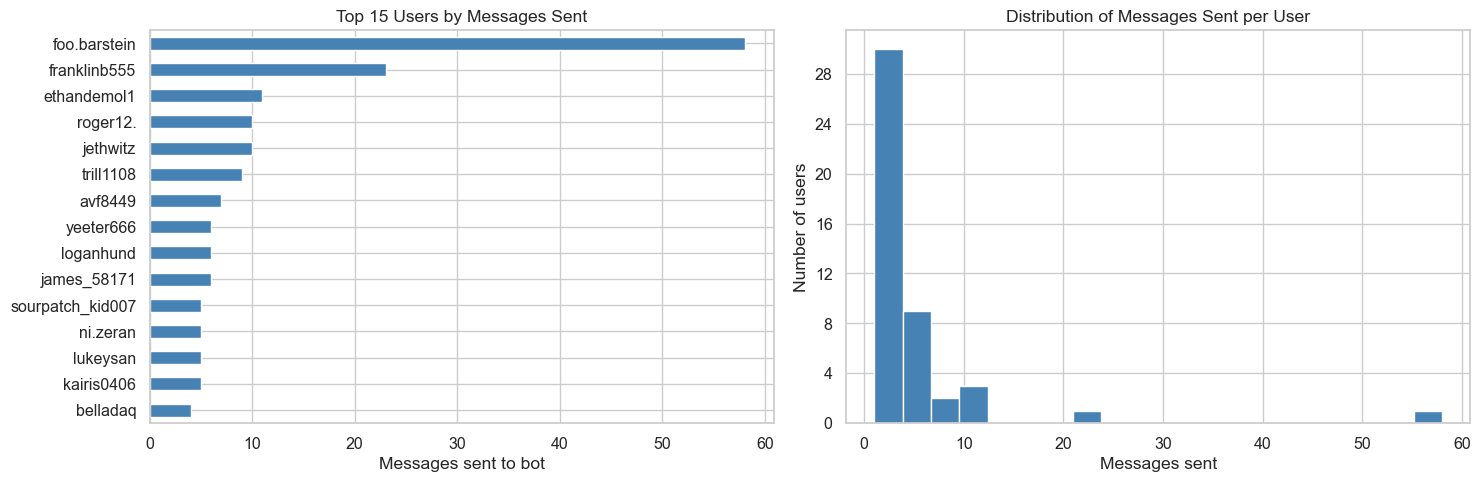

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 15 most active users
top_users = (
    msgs[msgs['direction'] == 'from']
    .groupby('discord_username')['id']
    .count()
    .nlargest(15)
    .sort_values()
)
top_users.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Users by Messages Sent')
axes[0].set_xlabel('Messages sent to bot')
axes[0].set_ylabel('')

# Distribution: how many messages did each user send?
per_user = msgs[msgs['direction'] == 'from'].groupby('user_id')['id'].count()
axes[1].hist(per_user, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Messages Sent per User')
axes[1].set_xlabel('Messages sent')
axes[1].set_ylabel('Number of users')
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 3. Conversations

Messages from the same user in the same channel are grouped into **conversations** when they occur within a rolling time window. A new conversation starts after a gap of more than `GAP_MINUTES` minutes of silence.

In [16]:
GAP = pd.Timedelta(minutes=GAP_MINUTES)

m = msgs.sort_values(['user_id', 'channel', 'created_at']).reset_index(drop=True)

# Time since the previous message from the same user in the same channel
m['tdiff']    = m.groupby(['user_id', 'channel'])['created_at'].diff()

# A new conversation starts when there is no previous message (first in group)
# or the gap exceeds the threshold
m['new_conv'] = m['tdiff'].isna() | (m['tdiff'] > GAP)

# Cumulative sum gives each conversation a unique integer ID
m['conv_id']  = m['new_conv'].cumsum()

print(
    'Identified', m['conv_id'].nunique(), 'conversations from',
    m['user_id'].nunique(), 'users'
    ' (gap threshold:', GAP_MINUTES, 'min)'
)

Identified 161 conversations from 46 users (gap threshold: 30 min)


In [17]:
def clean(text):
    text = re.sub(r'<@!?\d+>', '', text)        # remove Discord @mentions
    text = re.sub(r'^@\S+\s*,?\s*', '', text)   # remove leading @username token
    return text.strip()

convs = (
    m.groupby('conv_id')
    .agg(
        user_id      = ('user_id',          'first'),
        username     = ('discord_username', 'first'),
        course       = ('course',           'first'),
        semester     = ('semester',         'first'),
        channel      = ('channel',          'first'),
        channel_type = ('channel_type',     'first'),
        start_time   = ('created_at',       'min'),
        end_time     = ('created_at',       'max'),
        num_messages = ('id',               'count'),
        contents     = ('content',          list),
        directions   = ('direction',        list),
    )
    .reset_index()
)

convs['duration_mins'] = (
    (convs['end_time'] - convs['start_time']).dt.total_seconds() / 60
)

print(len(convs), 'conversations')
convs[['username', 'course', 'semester', 'channel_type', 'num_messages', 'duration_mins']].head(6)

161 conversations


,username,course,semester,channel_type,num_messages,duration_mins
0,foo.barstein,Software Engineering,Spring 2026,Global,2,0.333215
1,foo.barstein,Agile Software Development & DevOps,Spring 2026,Students,2,0.220974
2,foo.barstein,Agile Software Development & DevOps,Spring 2026,Global,2,0.182987
3,foo.barstein,Agile Software Development & DevOps,Spring 2026,Global,2,0.039066
4,foo.barstein,Software Engineering,Spring 2026,Global,2,0.786895
5,foo.barstein,Software Engineering,Spring 2026,Global,1,0.000000


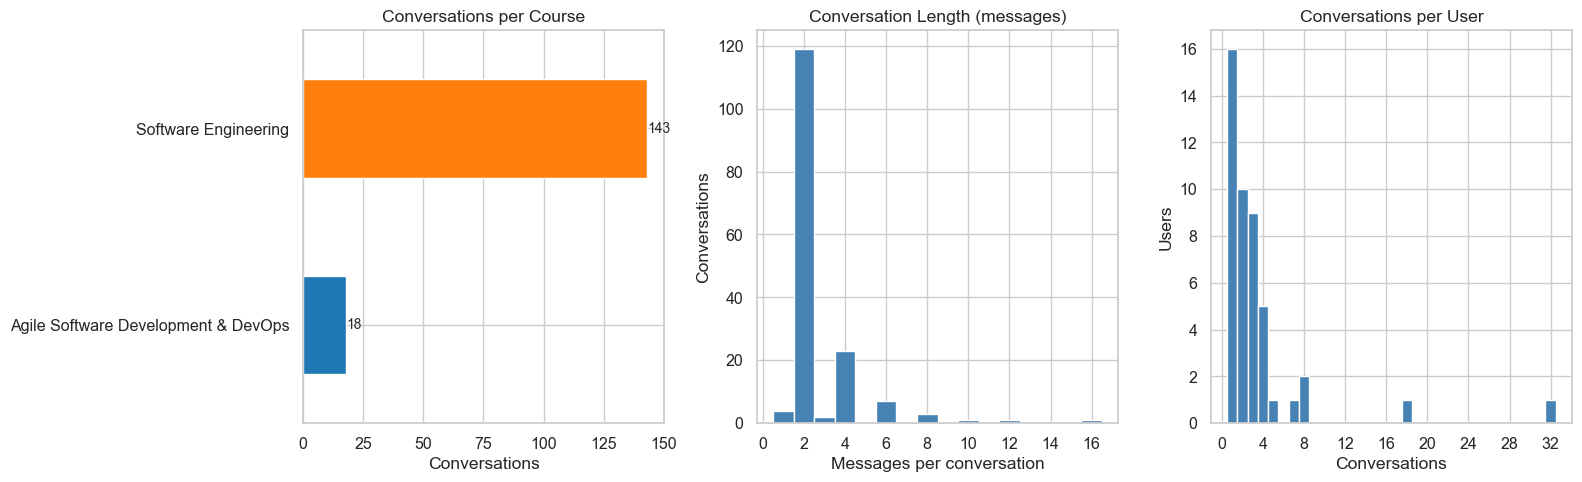

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Conversations per course
conv_by_course = convs.groupby('course')['conv_id'].count().sort_values()
conv_by_course.plot.barh(ax=axes[0], color=sns.color_palette('tab10'))
axes[0].set_title('Conversations per Course')
axes[0].set_xlabel('Conversations')
axes[0].set_ylabel('')
for bar, val in zip(axes[0].patches, conv_by_course):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)

# Conversation length distribution (message count)
max_msgs = int(convs['num_messages'].max())
axes[1].hist(convs['num_messages'], bins=range(1, max_msgs + 2),
             color='steelblue', edgecolor='white', align='left')
axes[1].set_title('Conversation Length (messages)')
axes[1].set_xlabel('Messages per conversation')
axes[1].set_ylabel('Conversations')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Conversations per user
convs_per_user = convs.groupby('user_id')['conv_id'].count()
axes[2].hist(convs_per_user, bins=range(1, int(convs_per_user.max()) + 2),
             color='steelblue', edgecolor='white', align='left')
axes[2].set_title('Conversations per User')
axes[2].set_xlabel('Conversations')
axes[2].set_ylabel('Users')
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Topic Classification

Each conversation is classified into one of the predefined topics using OpenAI. Results are cached in `data/topic_classifications.json` so re-running the notebook does not re-classify conversations already processed.

In [19]:
def load_cache():
    if CACHE_PATH.exists():
        return json.loads(CACHE_PATH.read_text())
    return {}

def save_cache(cache):
    CACHE_PATH.write_text(json.dumps(cache, indent=2))

def classify(contents, directions, course):
    text = '\n'.join(
        ('Student' if d == 'from' else 'Bot') + ': ' + clean(c)
        for c, d in zip(contents, directions)
    )
    topic_list_str = '\n'.join('- ' + t for t in TOPICS)
    resp = openai_client.chat.completions.create(
        model=CLASSIFICATION_MODEL,
        messages=[
            {
                'role': 'system',
                'content': (
                    'Classify this student conversation with a course bot for the course '
                    + repr(course)
                    + '. Choose exactly one topic from this list:\n'
                    + topic_list_str
                    + '\n\nReply with only the topic name, nothing else.'
                ),
            },
            {'role': 'user', 'content': text},
        ],
        max_tokens=20,
        temperature=0,
    )
    result = resp.choices[0].message.content.strip()
    for t in TOPICS:
        if result.lower().startswith(t[:12].lower()) or t.lower() in result.lower():
            return t
    return 'Other'

openai_client = OpenAI()
cache     = load_cache()
new_count = 0

topic_list = []
for _, row in convs.iterrows():
    key = str(int(row['conv_id']))
    if key in cache:
        topic_list.append(cache[key])
    else:
        topic = classify(row['contents'], row['directions'], row['course'])
        cache[key] = topic
        topic_list.append(topic)
        new_count += 1

save_cache(cache)
convs['topic'] = topic_list
print('Classified', new_count, 'new conversations,', len(convs) - new_count, 'loaded from cache.')
convs['topic'].value_counts()

Classified 161 new conversations, 0 loaded from cache.


topic
Team projects & collaboration     40
Technical setup & tools           30
Assignments & homework            25
Grades & assessment               24
Syllabus, schedule & deadlines    13
Course material & content         12
Other                             10
Resources & references             4
Professor & office hours           3
Name: count, dtype: int64

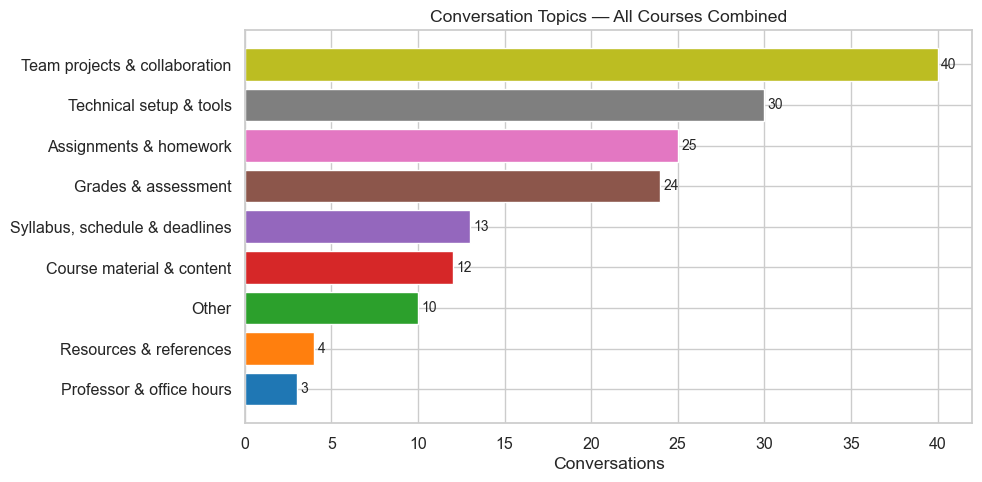

In [20]:
topic_counts = convs['topic'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    topic_counts.index,
    topic_counts.values,
    color=sns.color_palette('tab10', len(topic_counts)),
)
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)
ax.set_title('Conversation Topics — All Courses Combined')
ax.set_xlabel('Conversations')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

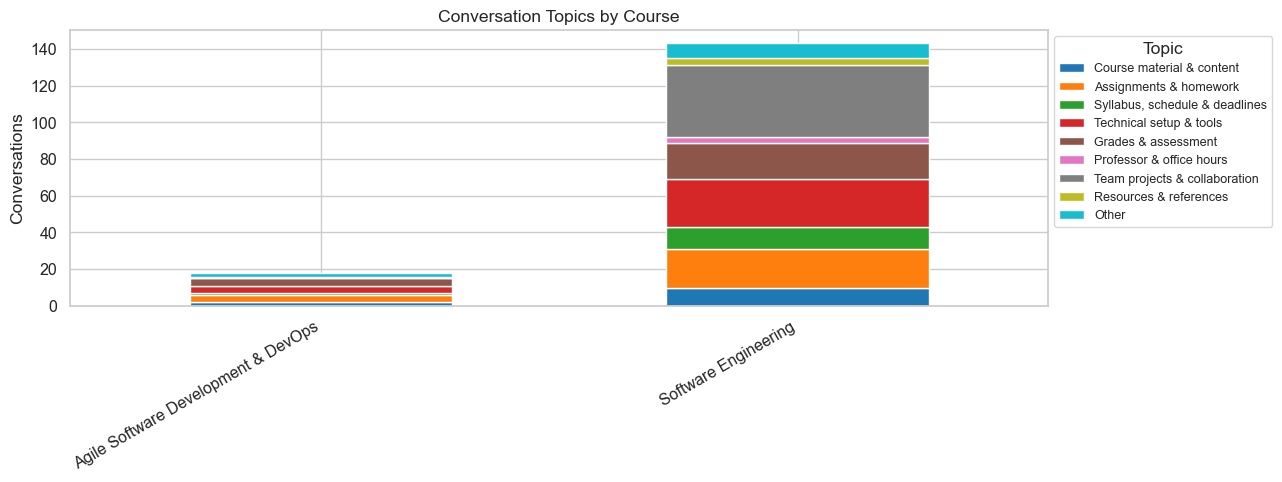

In [21]:
# Stacked bar: topics per course
topic_course = (
    convs.groupby(['course', 'topic'])['conv_id']
    .count()
    .unstack(fill_value=0)
    .reindex(columns=TOPICS, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
topic_course.plot.bar(stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.55)
ax.set_title('Conversation Topics by Course')
ax.set_xlabel('')
ax.set_ylabel('Conversations')
ax.legend(title='Topic', bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

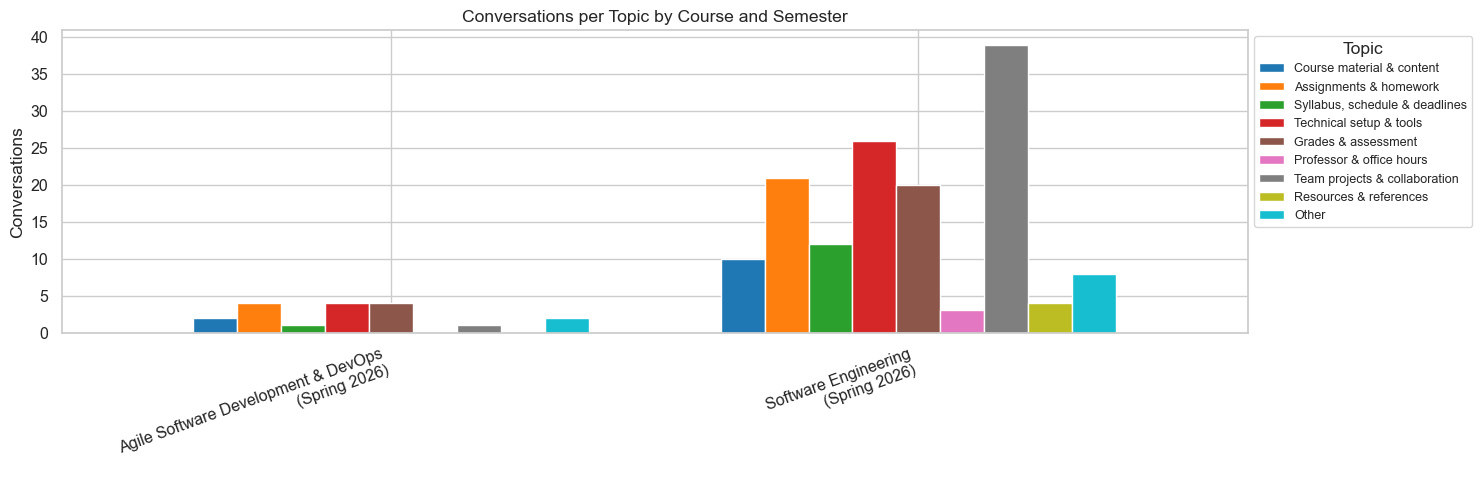

In [22]:
# Grouped bar: conversations per topic, split by course+semester
cs_topic = (
    convs.groupby(['course', 'semester', 'topic'])['conv_id']
    .count()
    .reset_index(name='conversations')
)
cs_topic['course_sem'] = cs_topic['course'] + '\n(' + cs_topic['semester'] + ')'

pivot2 = (
    cs_topic.pivot_table(
        index='course_sem', columns='topic',
        values='conversations', fill_value=0
    )
    .reindex(columns=TOPICS, fill_value=0)
)

fig, ax = plt.subplots(figsize=(15, 5))
pivot2.plot.bar(ax=ax, colormap='tab10', edgecolor='white', width=0.75)
ax.set_title('Conversations per Topic by Course and Semester')
ax.set_xlabel('')
ax.set_ylabel('Conversations')
ax.legend(title='Topic', bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

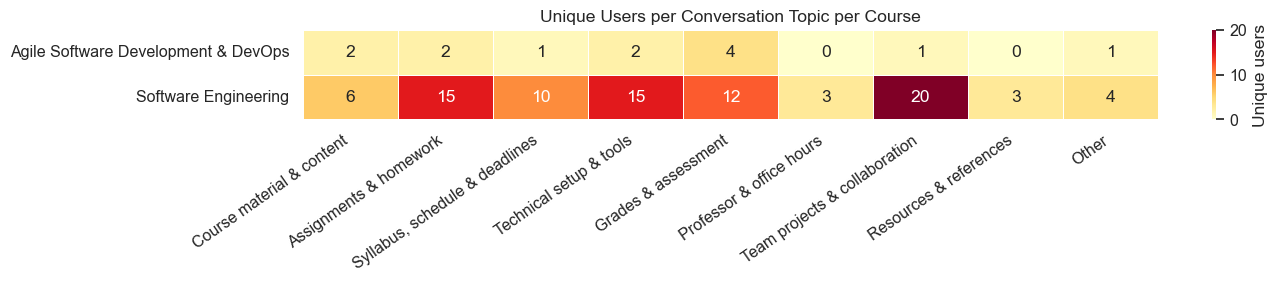

In [23]:
# Heatmap: unique users per topic per course
users_per_topic = (
    convs.groupby(['course', 'topic'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=TOPICS, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, max(3, len(users_per_topic) * 1.1)))
sns.heatmap(
    users_per_topic,
    annot=True, fmt='d', linewidths=0.4,
    cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Unique users'},
)
ax.set_title('Unique Users per Conversation Topic per Course')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

/var/folders/rl/zsmq7_5n7qb5hfn1x6h1j_wc0000gq/T/ipykernel_39464/1912254165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


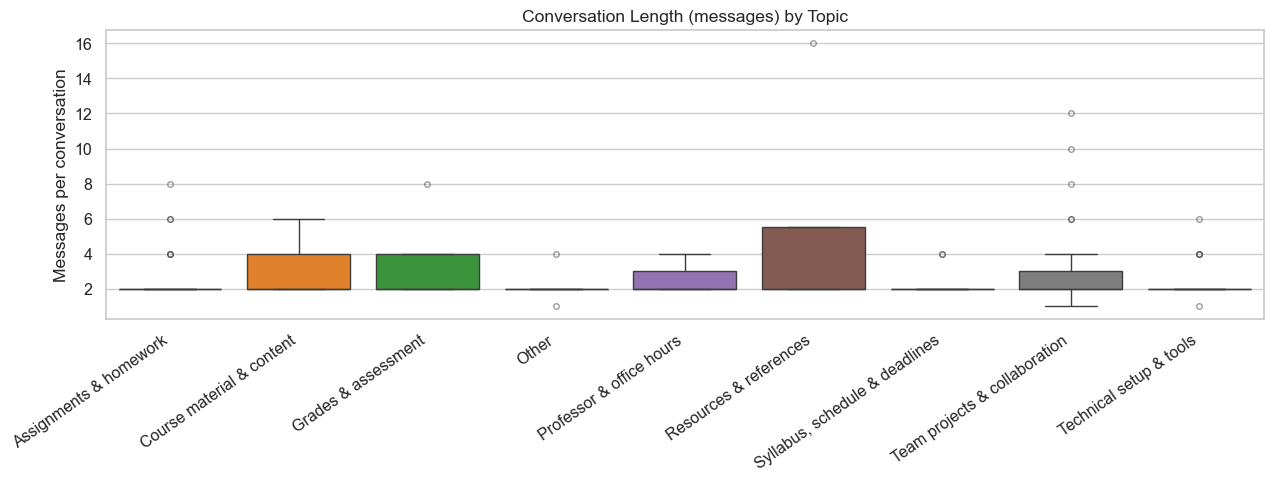

In [24]:
# Box plot: conversation length (messages) by topic
topic_order = (
    convs.groupby('topic')['num_messages']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=convs, x='topic', y='num_messages',
    order=topic_order, palette='tab10', ax=ax,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
ax.set_title('Conversation Length (messages) by Topic')
ax.set_xlabel('')
ax.set_ylabel('Messages per conversation')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5. Summary Table

In [25]:
summary_table = (
    convs
    .groupby(['course', 'semester', 'topic'])
    .agg(
        conversations    = ('conv_id',      'count'),
        unique_users     = ('user_id',      'nunique'),
        avg_msg_per_conv = ('num_messages', 'mean'),
        avg_duration_min = ('duration_mins','mean'),
    )
    .round(1)
    .reset_index()
    .sort_values(['course', 'semester', 'conversations'], ascending=[True, True, False])
    .reset_index(drop=True)
)

pd.set_option('display.max_rows', 100)
summary_table

,course,semester,topic,conversations,unique_users,avg_msg_per_conv,avg_duration_min
0,Agile Software Development & DevOps,Spring 2026,Assignments & homework,4,2,3.5,2.6
1,Agile Software Development & DevOps,Spring 2026,Grades & assessment,4,4,2.5,0.3
2,Agile Software Development & DevOps,Spring 2026,Technical setup & tools,4,2,3.0,0.4
3,Agile Software Development & DevOps,Spring 2026,Course material & content,2,2,3.0,1.7
4,Agile Software Development & DevOps,Spring 2026,Other,2,1,2.0,0.1
5,Agile Software Development & DevOps,Spring 2026,"Syllabus, schedule & deadlines",1,1,2.0,0.3
6,Agile Software Development & DevOps,Spring 2026,Team projects & collaboration,1,1,4.0,1.6
7,Software Engineering,Spring 2026,Team projects & collaboration,39,20,3.0,3.2
8,Software Engineering,Spring 2026,Technical setup & tools,26,15,2.2,0.5
9,Software Engineering,Spring 2026,Assignments & homework,21,15,2.7,2.7
